# Deep Learning for MRI reconstruction: about hallucinations and instabilities

In this tutorial, we will investigate the use of **deep learning models for the reconstruction of Magnetic Resonance Imaging (MRI) data**. You will reproduce experiments from:

 * *Gottschling, N. M., Antun, V., Hansen, A. C., & Adcock, B. (2025). The troublesome kernel: On hallucinations, no free lunches, and the accuracy-stability tradeoff in inverse problems. SIAM Review, 67(1), 73-104.* [[arxiv]](https://arxiv.org/pdf/2001.01258),


that uses machine learning models introduced in:
 
 * *Zhu, B., Liu, J. Z., Cauley, S. F., Rosen, B. R., & Rosen, M. S. (2018). Image reconstruction by domain-transform manifold learning. Nature, 555(7697), 487-492.*,

 *  *Schlemper, J., Caballero, J., Hajnal, J. V., Price, A., & Rueckert, D. (2017, May). A deep cascade of convolutional neural networks for MR image reconstruction. In International conference on information processing in medical imaging (pp. 647-658). Cham: Springer International Publishing.* [[arxiv]](https://arxiv.org/pdf/1703.00555).

The data used for this tutorial was modified from the [NYU fastMRI dataset](https://fastmri.med.nyu.edu/):

 * *Knoll et al. (2020). fastMRI: A Publicly Available Raw k-Space and DICOM Dataset of Knee Images for Accelerated MR Image Reconstruction Using Machine Learning. Radiology: Artificial Intelligence. doi: 10.1148/ryai.2020190007.* [[arxiv]](https://arxiv.org/pdf/1811.08839)




#### Structure of the repo

The code for running this tutorial is available at https://github.com/Romain3Ch216/DL4IA/tree/main/docs/tutorials/mri_restoration. We suggest to fork the [DL4IA](https://github.com/Romain3Ch216/DL4IA) repo and clone your fork:
```
git clone git@github.com:<your-username>/DL4IA.git

```

The repo contains the following files, with code **to be completed**.
```
mri_restoration
├── configs
    ├── automap.yaml
    ├── exp_deepnetmri.yaml
├── models
    ├── automap.py
    ├── deepnet_mri.py
├── dataset.py
├── mri_restoration.ipynb
├── train.py
├── utils.py
```

# MRI reconstruction: motivation and challenges

As stated by Knoll et al. (2020), "the excellent soft tissue contrast and flexibility of magnetic resonance imaging (MRI) makes it a very powerful diagnostic tool for a wide range of disorders [...]. However, the **long acquisition time** in MRI, which can easily exceed 30 minutes, leads to low patient throughput, **problems with patient comfort and compliance, artifacts from patient motion, and high exam costs**.".

"**MR imaging is an indirect process, whereby cross-sectional images of the subject’s anatomy are produced from frequency and phase measurements** instead of direct, spatially-resolved measurements." Hence, the measurement lies in the Fourier-space, called the k-space in medical imaging, and the image is computed through the inverse Fourier transform.

Let's plot the MRI raw k-space data. k-space data is complex: we therefore plot the module on one side and the phase on the other. Low-frequency components of the signal are located at the center of k-space, and high-frequency components at the periphery.

## Importations

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt

## Exemple de visualisation d'un k-space

In [2]:
data_folder = './data/brain_mri_singlecoil_slice_1' 
file_name = 'file_brain_AXT1POST_203_6000812.npy'
kspace = np.load(os.path.join(data_folder, file_name))

> On importe le k-space résultant d'un IRM. 
Le signal IRM est complexe (on peut afficher le module et la phase) :

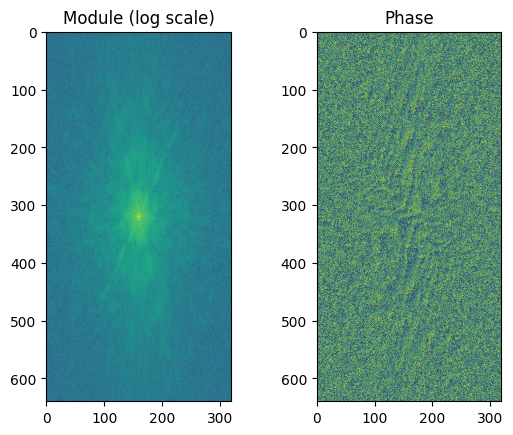

In [3]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(np.log(np.abs(kspace) + 1e-9))
ax[0].set_title('Module (log scale)')
ax[1].imshow(np.angle(kspace))
ax[1].set_title('Phase')
plt.show()

> L’IRM produit un k-space en encodant la position spatiale dans la phase et la fréquence du signal. L’image est ensuite reconstruite à l’aide d’une simple transformée de Fourier inverse : 

Transform and show the data in image space.

In [4]:
import numpy as np
image = np.fft.ifft2(kspace)

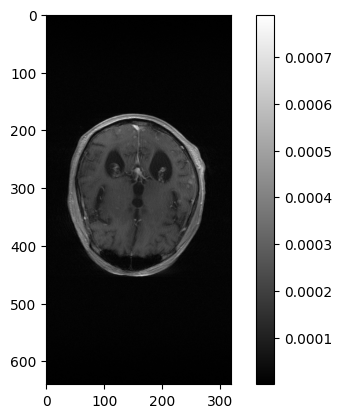

In [5]:
# Affichage : 
fig, ax = plt.subplots()
plt.imshow(np.abs(image), cmap='gray')
plt.colorbar()
plt.show()

## Undersampling

So, data is acquired by sampling the k-space up to a maximum frequency. The higher the maximum frequency, the longer the acquisition time. In order to decrease the acquisition time, Knoll et al. (2020) explain that "fewer samples can be captured by sampling up to a lower maximum frequency, however this produces images of lower spatial resolution. **An alternative undersampling approach involves omitting
some number of k-space samples within a given maximum frequency range, which then results in aliasing artifacts.**"

In the following, **we will simulate m-dimensional undersampled acquisition from N-dimensional fully-sampled acquisition**. The MRI acceleration methods result in columns ommited from the k-space data, with most of available data for low frequencies. We will perform 8-fold acceleration (*i.e.* the acceleration factor equals 8) and follow the procedure of (Knoll et al. 2020): the fully-sampled central region includes 4% of all k-space lines for 8-fold acceleration.

Update the function `kspace_mask` in `dataset.py` and show a random undersampling mask.

> Le sous-échantillonnage consiste à acquérir seulement une partie du k-space afin de réduire le temps d’acquisition. Les basses fréquences au centre sont généralement conservées, tandis que certaines lignes correspondant aux hautes fréquences sont omises, ce qui accélère l’acquisition en IRM. Ici, nous simulons ce processus de manière artificielle en sous-échantillonnant un k-space complet :

In [6]:
np.random.seed(3)   # seed pour que le processus soit reproductible
#from dataset import kspace_mask # Code d'origine : problème sur l'import ? 
from dataset import fastMriData

In [7]:
mask = fastMriData.kspace_mask(kspace.shape, acceleration_factor=8) # récupérer un masque random sur le k-space importé plus tôt

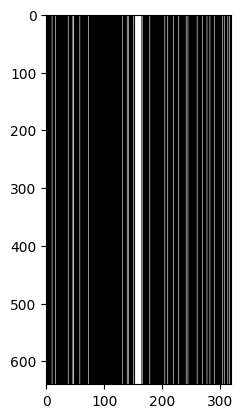

In [8]:
# affichage
fig = plt.figure()
plt.imshow(
    mask.unsqueeze(0).repeat(kspace.shape[0], 1),
    cmap='gray'
)
plt.show()

> On voit bien que les colonnes centrales sont conservées (basses fréquences = majorité du signal), et que le reste des colonnes sont échantillonées aléatoirement.

Use the mask to simulate an under-sampled acquisition. Show the zero-filled reconstruction (i.e. the reconstructed image from the under-sampled k-space measurement filled with zeros where there is no data).

In [9]:
import torch 
obs_kspace = np.zeros_like(kspace)  # on construit une matrice de taille kspace.shape, remplie de 0 (complexe)
obs_kspace[:,mask]=kspace[:,mask]   # on remplace par la valeur dans kspace si mask=1
obs_image = np.abs(np.fft.ifft2(obs_kspace)) # transformée de fourier inverse

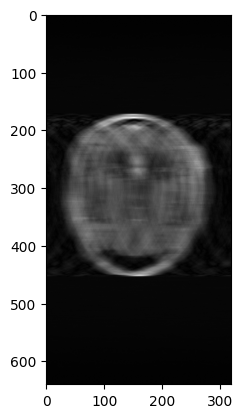

In [10]:
# affichage
fig = plt.figure()
plt.imshow(obs_image, cmap='gray')
plt.show()

> Après reconstruction du k-space sous-échantillonné, on observe que les contours et les formes globales sont conservés, mais que la reconstruction reste floue et peu informative.

Undersampling leads to an **information loss**, framing the problem of MRI reconstruction as an **ill-posed inverse problem**:
$$\text{Given measurements } y = Ax + e, \text{ recover } x.$$
where $x \in \mathbb{C}^N$ is the fully-sampled MRI, $y \in \mathbb{C}^m$ is the under-sampled k-space observation, $A$ is the sampling operator (the Fourier transform and the undersampling), and $e$ is a measurement noise. The problem is ill-posed (it does not admit a unique solution) because the **kernel $\mathcal{N}(A)$ of the sampling operator is nontrivial** (as $m < N$):
$$\mathcal{N}(A) := \{x \vert Ax = 0\} \neq \{0\}$$

In this tutorial, we are interested in methods that learn a reconstruction map $\hat{\Psi} : \mathbb{C}^m \longrightarrow \mathbb{C}^N$ from a training set $\mathcal{T} = \{(y_i, x_i)\}_{i=1}^K$ where $y_i = Ax_i + e_i$.

# MRI reconstruction: DL models can hallucinate due to detail transfer

We are going to look at the first result of (Gottschling et al., 2025).

**[Main result 2.1]** Let $x \in \mathbb{C}^N$ and $x_{det}$ be a detail that either belongs to $\mathcal{N}(A)$ or lies close to it (i.e., $\|Ax_{det}\| \ll 1$ for some norm $\|\cdot\|$). Then, any map $\Psi$ that recovers the detail image $x + x_{det}$ will hallucinate by incorrectly transferring this detail when reconstructing the detail-free image $x$, i.e. $\Psi(Ax + e) \approx x + x_{det}$.

Besides, Gottschling et al. emphasize on the fact that **this is not a statement about overfitting**. Their result applies for all mappings, including neural networks that do not overfit.

In the Figure 2 of their paper, they illustrate this result on a toy example. In this tutorial, we are going to illustrate this transfer detail on a toy example as well, with a neural network trained on a single data point. The data is available in the `exp_fig_2` folder:

* `file_brain_AXT1POST_203_6000812.npy` is a MRI sample, that we will denote as $x_1$,
  
* `file_brain_AXT1POST_203_6000812_apt.npy` is the same MRI sample corrupted with a small detail, that we will denote as $x_2 = x_1 + x_{det}$.

Show the measurements and the targets, and compute $\|Ax_{det}\|_2$.

In [11]:
import torch
import yaml
from dataset import fastMriData

In [12]:
cfg_file = 'configs/automap.yaml'
exp_fig2_data_folder = './data/exp_fig_2'

with open(cfg_file, 'r') as file:
    cfg = yaml.safe_load(file)

dataset = fastMriData(exp_fig2_data_folder, mask=mask, mean=cfg['data_mean'], std=cfg['data_std'])
# construction d'un dataset pytorch 

> **Sorties de (`__getitem__`) :**
> - **image** : image dégradée obtenue après sous-échantillonnage du k-space et reconstruction
> - **kspace** : k-space associé à cette image dégradée
> - **target_image** : image cible reconstruite à partir du k-space complet
> - **target_kspace** : k-space correspondant à l'image cible

In [13]:
image, kspace, target_image, target_kspace = dataset.__getitem__(0)
image_det, kspace_det, target_image_det, target_kspace_det = dataset.__getitem__(1)

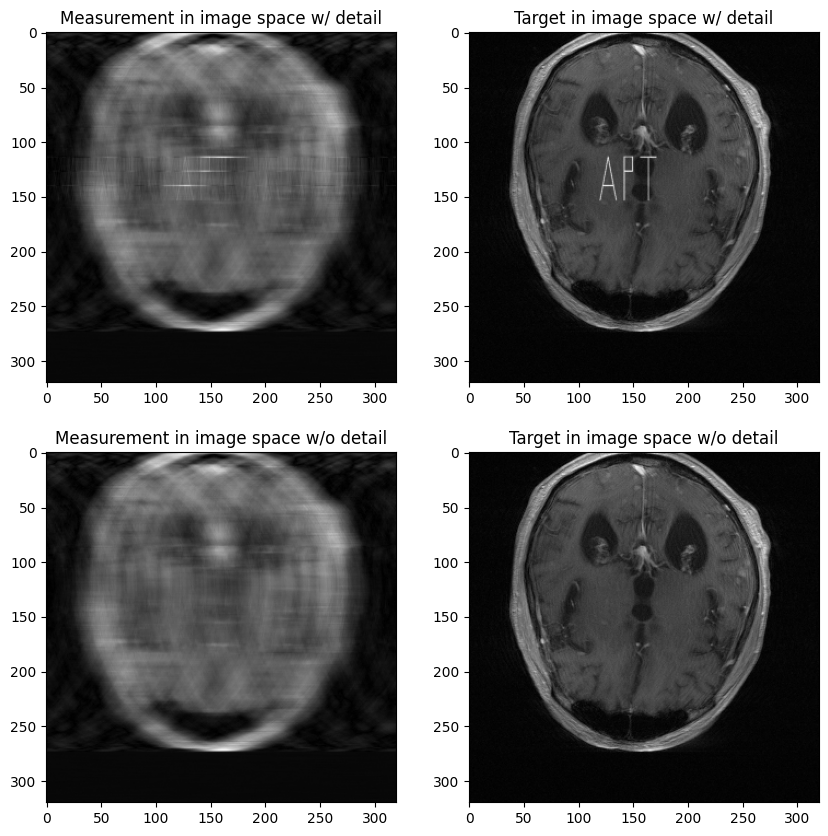

In [14]:
# affichage
fig, ax = plt.subplots(2, 2, figsize=(10,10))
ax[1, 0].imshow(image, cmap='gray')
ax[1, 1].imshow(target_image, cmap='gray')
ax[0, 0].imshow(image_det, cmap='gray')
ax[0, 1].imshow(target_image_det, cmap='gray')
ax[1, 0].set_title('Measurement in image space w/o detail')
ax[1, 1].set_title('Target in image space w/o detail')
ax[0, 0].set_title('Measurement in image space w/ detail')
ax[0, 1].set_title('Target in image space w/ detail')
plt.show()

> On obtient les images « dégradées » issues de la reconstruction à partir du k-space sous-échantillonné, ainsi que les images « target » reconstruites à partir du k-space complet, pour deux images : l’une sans détail et l’autre contenant un détail.

> Maintenant, calculons $\|Ax_{det}\|_2$.
On s'attend à avoir $A(x_1​+x_{det}​)≈Ax_1​$, et donc $\|Ax_{det}\|_2$ proche de 0.

In [15]:
# on a x_det = x2-x1 :
x_det = target_image_det - target_image 

# A x_det = fft + undersampling de x_det
kspace_xdet = torch.fft.fftn(x_det) # fft

Ax_det = torch.zeros_like(kspace_xdet)
Ax_det[:, mask] = kspace_xdet[:, mask]   # on applique le même masque que plus tôt
# on obtient bien Ax_det

# calcul de la norme : 
torch.norm(Ax_det)

tensor(4848.9204)

> Pour pouvoir comparer, calculons $\|Ax_1\|_2$ :

In [16]:
# A x_1 = fft + undersampling de x_det
kspace_x1 = torch.fft.fftn(target_image) # fft

Ax1 = torch.zeros_like(kspace_x1)
Ax1[:, mask] = kspace_x1[:, mask]   # on applique le même masque que plus tôt
# on obtient bien Ax_1

# calcul de la norme : 
torch.norm(Ax1)

tensor(28119.9082)

In [17]:
# faisons un ratio :
torch.norm(Ax_det)/torch.norm(Ax1)

tensor(0.1724)

> Le ratio de 17 % indique que le détail modifie assez peu les mesures, bien que son effet ne soit pas nul. On aurait pu s’attendre à une valeur plus faible, mais le détail ajouté (le lettrage « APT ») est relativement visible et intense, ce qui peut expliquer ce résultat car il reste probablement en partie présent dans les basses fréquences (conservées par le masque de sous-échantillonnage).

# AUTOMAP 

In `models/automap.py`, define the AUTOMAP model introduced in (Zhu et al., 2018), and illustrated by (Gottschling, 2022). AUTOMAP takes as input the observed k-space data, and outputs the target data in image space. Instead of a hidden dimension of 25000 at the second layer, use a dimension of 64.

<center>
    <img src="figures/automap.png" width=800>
</center>
<center>
    Source: <a href="https://www.repository.cam.ac.uk/items/f24dce55-9d82-4515-8124-ede37e935657">(Gottschling, 2022)</a>
</center>


Train the Automap model to reconstruct $x_2$ with the `train.py` script, and show its reconstruction of the observations with and without the detail.

In [18]:
from models.automap import Automap

In [19]:
#!python train.py --cfg_file configs/automap.yaml

In [20]:
K = cfg['kspace_shape'][0]
m = cfg['kspace_shape'][0] * (cfg['kspace_shape'][1] // cfg['acceleration_factor'] - 1)
model_cfg = cfg['model']
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = Automap(m, K, **model_cfg)

In [21]:
checkpoint_path = 'results/best_model.pth.tar' 
checkpoint = torch.load(checkpoint_path, map_location=device)


if 'model' in checkpoint:
    model.load_state_dict(checkpoint['model'])
    print("Succès : Les poids ont été extraits de la clé 'model' !")
else:
    model.load_state_dict(checkpoint)

model.to(device)

Succès : Les poids ont été extraits de la clé 'model' !


Automap(
  (res): Sequential(
    (0): Linear(in_features=24960, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=102400, bias=True)
    (3): Unflatten(dim=1, unflattened_size=(1, 320, 320))
    (4): Conv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): Tanh()
    (6): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (7): ReLU()
    (8): ConvTranspose2d(64, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
  )
)

In [22]:
# prédictions de image (sans APT) et image_det (avec APT)

model.eval()

kspace = kspace.to(device)
kspace_det = kspace_det.to(device)
mask = mask.to(device)

with torch.no_grad():
    rec = model(kspace.unsqueeze(0), mask)
    rec_det = model(kspace_det.unsqueeze(0), mask)

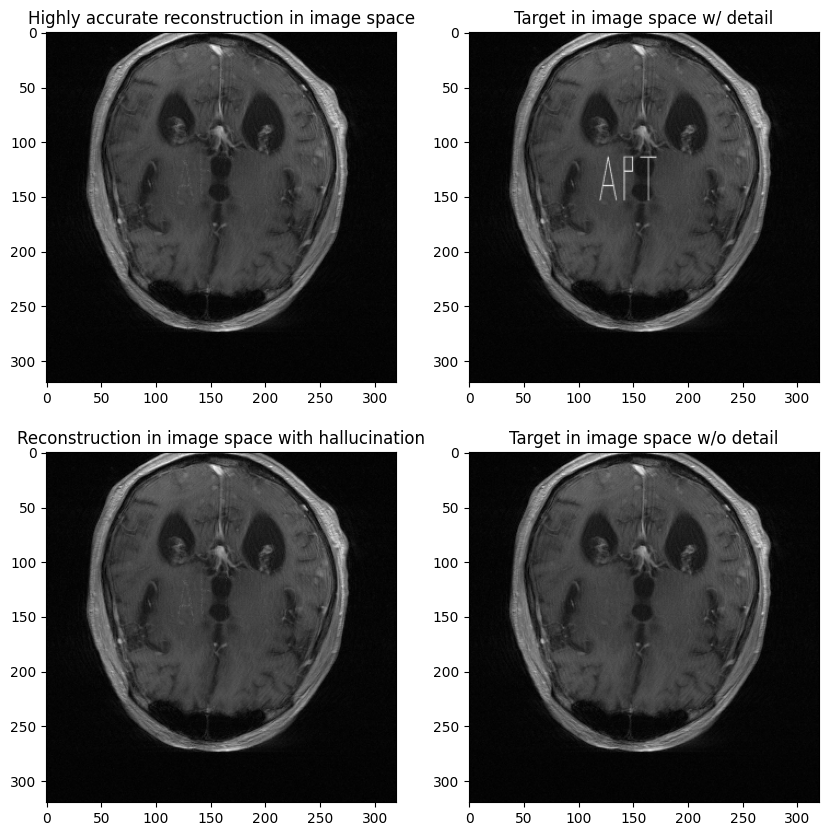

In [23]:
min_value = target_image.min()
max_value = target_image.max()

fig, ax = plt.subplots(2, 2, figsize=(10,10))
ax[0, 0].imshow(rec_det.squeeze(0).cpu(), cmap='gray', vmin=min_value, vmax=max_value)
ax[0, 0].set_title('Highly accurate reconstruction in image space')

ax[0, 1].imshow(target_image_det, cmap='gray', vmin=min_value, vmax=max_value)
ax[0, 1].set_title('Target in image space w/ detail')

ax[1, 0].imshow(rec.squeeze(0).cpu(), cmap='gray', vmin=min_value, vmax=max_value)
ax[1, 0].set_title('Reconstruction in image space with hallucination')

ax[1, 1].imshow(target_image, cmap='gray', vmin=min_value, vmax=max_value)
ax[1, 1].set_title('Target in image space w/o detail')
plt.show()

# modèle prédit à tord "APT" dans le deuxième cas

> On observe des reconstructions globalement satisfaisantes. Le détail apparaît à la fois dans rec_det et dans rec, comme attendu.
> Toutefois, le détail (le lettrage "APT") apparaît de manière très subtile, on s’attendrait à le distinguer beaucoup plus clairement. Malgré plusieurs vérifications de l’implémentation, nous n’avons pas identifié d’erreur évidente dans le code (peut-être la taille du bottleneck qui a été diminuée pour l'expérience). Le modèle a ici été entraîné pendant 10 000 epochs.

# MRI reconstruction: accuracy - stability / hallucination trade-off of DL models

In this section, we are going to look at the third result of (Gottschling et al., 2025).

**[Main result 2.3]** Consider two distinct images $x, x'$ whose difference lies in or close to $\mathcal{N}(A)$, i.e., $\|A(x - x')\| \ll 1$ for some norm $\|\cdot\|$. If $\Psi$ recovers both $x$ and $x'$ well (overperformance), or recovers $x$ well and $x'$ poorly (inconsistent performance), then the following must holf:

* $\Psi$ is unstable in a ball around $y = Ax$, with the instability becoming worse as the reconstruction performance improves.

* $\Psi$ hallucinates in a ball around $y = Ax$: there are small perturbations $e$ for which, when given measurements $Ax + e$, $\Psi$ produces false details not in the image $x$.

This result is illustrated in Figure 3 of the paper. We are going to reproduce a variant of this figure, using a CNN introduced in (Schlemper et al., 2017) with pretrained parameters. Their CNN (illustrated below) takes as **input the (zero-filled) observed data in image space, and performs de-aliasing through convolutional layers**. In order to impose consistecy of the CNN prediction with observed data, they include at the end of the convolutional layers a **data consistency (DC) layer**. The DC layer **enforces the prediction in k-space to equal the available measurements in k-space**. In addition, Schlemper et al. argue that "while CNNs may be powerful enough to learn one step reconstruction, such network could indicate signs of overfitting, unless we have vast amounts of training data". Therefore, they "concatenate a new CNN on the output of the previous CNN to build extremely deep networks which iterate between intermediate de-aliasing and the data consistency reconstruction."
<center>
    <img src="figures/deepnetmri.png" width=700>
</center>
<center>
    Source: <a href="https://arxiv.org/pdf/1703.00555">(Schlemper et al., 2017)</a>
</center>

Update the `DeepNetMri`class and load a pretrained model.

In [24]:
from scipy.io import loadmat
import yaml
#from deepnet_mri import DeepNetMRI # ne marche pas
from models.deepnet_mri import DeepNetMRI

In [25]:
with open('configs/exp_deepnetmri.yaml', 'r') as file:
    cfg = yaml.safe_load(file)

model_cfg = cfg['model']
print(model_cfg)
model = DeepNetMRI(n_channels=2, **model_cfg)

{'nc': 5, 'nd': 5, 'nf': 64, 'kernel_size': 3, 'noise_level': None}


In [26]:
# load model
checkpoint_path = './data/exp_fig_3/d5_c5.pth.tar' 
checkpoint = torch.load(checkpoint_path, map_location=device)

if 'model' in checkpoint:
    model.load_state_dict(checkpoint['model'])
    print("Succès : Les poids ont été extraits de la clé 'model' !")
else:
    model.load_state_dict(checkpoint)

model.to(device)

DeepNetMRI(
  (cascaded_cnns): ModuleList(
    (0-4): 5 x CNN(
      (layers): ModuleList(
        (0): Sequential(
          (0): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU()
        )
        (1-3): 3 x Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU()
        )
        (4): Conv2d(64, 2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
  )
  (dc_layer): DataConsistency()
)

We are going to use a cardiac MRI sample.

In [27]:
data = loadmat(os.path.join(cfg['exp_folder'], 'x0.mat'))
target_image = data['x0'][0] + data['x0'][1] * 1j
target_image = torch.as_tensor(target_image)

mask = loadmat(os.path.join(cfg['exp_folder'], 'mask.mat'))
mask = torch.as_tensor(mask['mask'][0]).long() == 1
mask = torch.fft.fftshift(mask)

In [28]:
target_image.shape

torch.Size([256, 256])

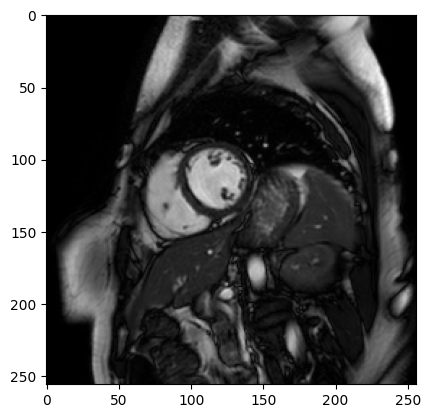

In [29]:
fig = plt.figure()
plt.imshow(torch.abs(target_image), cmap='gray')
plt.show()

In the `exp_fig_3` folder are worst-case perturbations, i.e., noise optimized to distort the prediction of the model while being as small as possible. Apply those perturbations to the data. Are those perturbations visible in image space? Is the CNN unstable or does it hallucinate?

> Ici, on ajoute plusieurs fonctions utilitaires : 
> - **noisy_measurement :** on simule un processus IRM bruité (ajout de bruit sur le kspace, sous-échantillonage des colonnes avec le masque, transformée de fourier inverse pour obtenir l'image correspondante)
> - **deprocess_obs :** prépare les images reconstruites à partir du kspace incomplet et bruité pour l'affichage (récupération du module de l'image complexe) 
> - **deprocess_rec :** prépare les prédictions du modèles pour l'affichage (passage d'une dimension (B,C,256,256) à (256,256) en valeur absolue)
> - **deprocess_target :** prépare les images reconstruites à partir du k-space complet pour l'affichage (récupération du module de l'image complexe) 

In [30]:
def noisy_measurement(kspace: torch.Tensor, mask: torch.Tensor, target_image: torch.Tensor = None, noise: torch.Tensor = None, return_target = False):
    """Simulates a noisy MRI measurement.
    """
    if noise is not None : 
        kspace=kspace+noise
    obs_kspace = torch.zeros_like(kspace)  # on construit une matrice de taille kspace.shape, remplie de 0 (complexe)
    obs_kspace[mask]=kspace[mask]   # !attention masque 2D ici!

    obs_image = torch.fft.ifft2(obs_kspace) # transformée de fourier inverse

    if return_target :  # renvoie target si true
        return obs_kspace, obs_image, target_image
    
    return obs_kspace, obs_image
    # obs kspace = kspace sous échantillonné voire bruité ; obs_image = reconstruction en espace image de obs kspace

def deprocess_obs(x):
    """Prepare observation data for plots.
    """
    if x.shape[0] == 1:
        x = x.squeeze(0)
    x=torch.abs(x)  # on récupère le module = ce qu'on veut afficher
    x = x.detach().cpu().numpy()
    return x

def deprocess_rec(x):
    """Prepare reconstruction for plots.
    """
    x=x.permute(0,2,3,1).squeeze(0)
    x=torch.view_as_complex(x)
    x=torch.abs(x)
    x = x.detach().cpu().numpy()
    return x

def deprocess_target(x):
    """Prepare target data for plots.
    """
    x=torch.abs(x)
    x = x.detach().cpu().numpy()
    return x

In [31]:
target_kspace = torch.fft.fftshift(torch.fft.fftn(target_image))

noise1 = torch.load(os.path.join(cfg['exp_folder'], 'worst_case_perturbation.pt'))
noise2 = torch.load(os.path.join(cfg['exp_folder'], 'worst_case_perturbation_zone_1.pt'))
noise3 = torch.load(os.path.join(cfg['exp_folder'], 'worst_case_perturbation_zone_2.pt'))

obs_kspace, obs_image = noisy_measurement(target_kspace, mask)
obs_kspace1, obs_image1, target_image1 = noisy_measurement(target_kspace, mask, target_image, noise1, return_target=True)
obs_kspace2, obs_image2, target_image2 = noisy_measurement(target_kspace, mask, target_image, noise2, return_target=True)
obs_kspace3, obs_image3, target_image3 = noisy_measurement(target_kspace, mask, target_image, noise3, return_target=True)

In [32]:
print("Shape of obs_kspace1 :",obs_kspace1.shape)
print("Shape of obs_image1 :",obs_image1.shape)
print("Shape of target_image1 :",target_image1.shape)

Shape of obs_kspace1 : torch.Size([256, 256])
Shape of obs_image1 : torch.Size([256, 256])
Shape of target_image1 : torch.Size([256, 256])


> On fait passer les données en inférence du modèle dont on a chargé les poids/checkpoint : 

In [33]:
# tout envoyer sur gpu (éviter bug gpu/cpu)
model.eval()    # éviter les comportements d'entrainement type dropout...
obs_image, obs_kspace, mask = [t.to(device) for t in (obs_image, obs_kspace, mask)]
obs_image1, obs_kspace1 = [t.to(device) for t in (obs_image1, obs_kspace1)]
obs_image2, obs_kspace2 = [t.to(device) for t in (obs_image2, obs_kspace2)]
obs_image3, obs_kspace3 = [t.to(device) for t in (obs_image3, obs_kspace3)]

with torch.no_grad():
    rec = model(obs_image, obs_kspace, mask)
    rec1 = model(obs_image1, obs_kspace1, mask)
    rec2 = model(obs_image2, obs_kspace2, mask)
    rec3 = model(obs_image3, obs_kspace3, mask)

In [34]:
print("Shape of reconstruction :",rec.shape)

Shape of reconstruction : torch.Size([1, 2, 256, 256])


In [35]:
target_image = deprocess_target(target_image)
target_image1 = deprocess_target(target_image1)
target_image2 = deprocess_target(target_image2)
target_image3 = deprocess_target(target_image3)

min_val, max_val = target_image.min(), target_image.max()

> Affichage : 

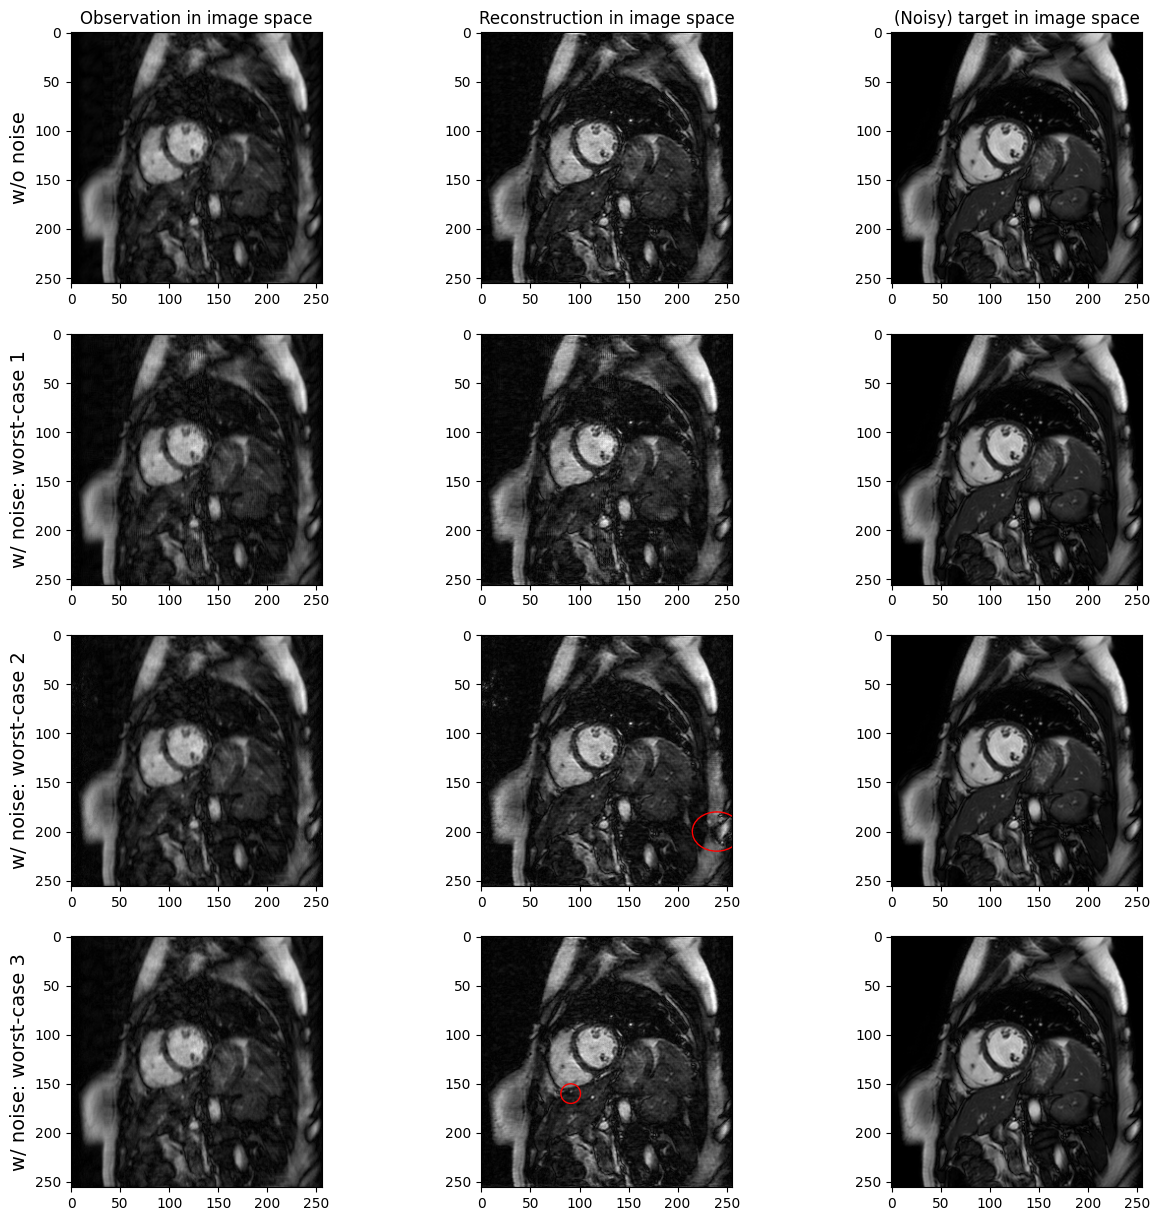

In [36]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(4, 3, figsize=(15, 15))
ax[0, 0].imshow(deprocess_obs(obs_image), cmap='gray', vmin=min_val, vmax=max_val)
ax[0, 1].imshow(deprocess_rec(rec), cmap='gray', vmin=min_val, vmax=max_val)
ax[0, 2].imshow(target_image, cmap='gray', vmin=min_val, vmax=max_val)
ax[0, 0].set_title('Observation in image space')
ax[0, 1].set_title('Reconstruction in image space')
ax[0, 2].set_title('(Noisy) target in image space')
    
ax[1, 0].imshow(deprocess_obs(obs_image1), cmap='gray', vmin=min_val, vmax=max_val)
ax[1, 1].imshow(deprocess_rec(rec1), cmap='gray', vmin=min_val, vmax=max_val)
ax[1, 2].imshow(target_image1, cmap='gray', vmin=min_val, vmax=max_val)

ax[2, 0].imshow(deprocess_obs(obs_image2), cmap='gray', vmin=min_val, vmax=max_val)
ax[2, 1].imshow(deprocess_rec(rec2), cmap='gray', vmin=min_val, vmax=max_val)
ax[2, 2].imshow(target_image2, cmap='gray', vmin=min_val, vmax=max_val)
ellipse = Ellipse((240, 200), width=50, height=40, edgecolor='red', facecolor='none', linewidth=1)
ax[2, 1].add_patch(ellipse)

ax[3, 0].imshow(deprocess_obs(obs_image3), cmap='gray', vmin=min_val, vmax=max_val)
ax[3, 1].imshow(deprocess_rec(rec3), cmap='gray', vmin=min_val, vmax=max_val)
ax[3, 2].imshow(target_image3, cmap='gray', vmin=min_val, vmax=max_val)
ellipse = Ellipse((91, 160), width=20, height=20, edgecolor='red', facecolor='none', linewidth=1)
ax[3, 1].add_patch(ellipse)

fontsize=14
ax[0, 0].set_ylabel('w/o noise', fontsize=fontsize)
ax[1, 0].set_ylabel('w/ noise: worst-case 1', fontsize=fontsize)
ax[2, 0].set_ylabel('w/ noise: worst-case 2', fontsize=fontsize)
ax[3, 0].set_ylabel('w/ noise: worst-case 3', fontsize=fontsize)

plt.show()

> Réponse à la question *'Are those perturbations visible in image space? Is the CNN unstable or does it hallucinate?'* :
> - **Dans les cas de perturbations n°2 et n°3**, on observe des hallucinations visibles dans l’espace image (signalées par les ellipses). Le modèle reconstruit des structures qui ne sont pas présentes dans l’image originale.
> - En revanche, nous ne parvenons pas à reproduire exactement les reconstructions attendues **pour le cas "sans bruit" et pour la perturbation n°1** (en comparaison avec le notebook fourni sur le dépôt GitHub). Dans la figure de référence, la reconstruction sans bruit est parfaite, comme attendu, tandis que la perturbation n°1 entraîne une forte instabilité du modèle, produisant d’importants artefacts et une reconstruction fortement dégradée. Malgré de nombreux essais et vérifications de l’implémentation, nous n’avons pas réussi à reproduire ces deux reconstructions de manière parfaitement équivalente au notebook originel.

> **En conclusion :** 
> - **Cas 1 :** la petite perturbation appliquée dans l’espace des mesures entraîne une reconstruction très différente de l’image originale. Cela illustre une instabilité du modèle.
> - **Cas 2 et 3 :** la reconstruction contient des structures artificielles absentes de l’image originale, visibles dans les régions entourées par les ellipses. Ces cas correspondent à des hallucinations du modèle.

#### Finally, write a script to compute new worst-case perturbations.

> Comment obtenir une "worst-case perturbation" ? On cherche un bruit $e$ ajouté aux mesures MRI (le k-space) qui :
> - est le plus petit possible
> - mais détruit le plus possible la reconstruction du réseau.

> C’est exactement le principe des attaques adversariales en deep learning. On cherche le plus petit bruit possible qui maximise l'erreur du réseau. On peut procéder en utilisant les gradients → on modifie le bruit *e* dans la direction qui augmente l'erreur.

In [130]:
# reload everything
data = loadmat(os.path.join(cfg['exp_folder'], 'x0.mat'))
target_image = data['x0'][0] + data['x0'][1] * 1j
target_image = torch.as_tensor(target_image)

mask = loadmat(os.path.join(cfg['exp_folder'], 'mask.mat'))
mask = torch.as_tensor(mask['mask'][0]).long() == 1
mask = torch.fft.fftshift(mask)

target_kspace = torch.fft.fftshift(torch.fft.fftn(target_image))

In [131]:
print("target image shape:",target_image.shape)
print("mask shape:",mask.shape)
print("target kspace shape:",target_kspace.shape)

target image shape: torch.Size([256, 256])
mask shape: torch.Size([256, 256])
target kspace shape: torch.Size([256, 256])


In [137]:
import torch.optim as optim

n_steps=700
eps=1e-2
lr = 1e-2

noise = torch.zeros_like(target_kspace)
noise.requires_grad=True

optimizer = optim.Adam([noise], lr=lr)
criterion = torch.nn.L1Loss()

model.eval()

target_kspace = target_kspace.to(device)
noise = noise.to(device)
mask = mask.to(device)

for i in range(n_steps): # gradient n'augmente plus?
    obs_kspace, obs_image = noisy_measurement(target_kspace, mask, target_image, noise)
    rec = model(obs_image, obs_kspace, mask)    # reconstruction avec le modèle

    loss = -criterion(rec,target_image) # on maximise la loss au lieu de la minimiser
    loss.backward()
    optimizer.step()

    noise.real.data = torch.clamp(noise.real.data, -eps, eps) # garder un noise petit
    noise.imag.data = torch.clamp(noise.imag.data, -eps, eps) # clamp marche pas pour les deux en même temps
    optimizer.zero_grad()

    if i%50==0:
        print("Loss at step n°",i,": ", -loss.item())

Loss at step n° 0 :  0.16023099422454834
Loss at step n° 50 :  0.1631258726119995
Loss at step n° 100 :  0.16581839323043823
Loss at step n° 150 :  0.16832929849624634
Loss at step n° 200 :  0.17074356973171234
Loss at step n° 250 :  0.17315401136875153
Loss at step n° 300 :  0.17547522485256195
Loss at step n° 350 :  0.17766758799552917
Loss at step n° 400 :  0.1797768920660019
Loss at step n° 450 :  0.18183761835098267
Loss at step n° 500 :  0.18384428322315216
Loss at step n° 550 :  0.1857437789440155
Loss at step n° 600 :  0.18756559491157532
Loss at step n° 650 :  0.18933475017547607


> On a bien une augmentation de la loss !

In [138]:
# on applique le noise ainsi obtenu :
obs_kspace, obs_image = noisy_measurement(target_kspace, mask, target_image, noise)

# tout envoyer sur gpu (éviter bug gpu/cpu)
model.eval()    # éviter les comportements d'entrainement type dropout...
obs_image, obs_kspace, mask = [t.to(device) for t in (obs_image, obs_kspace, mask)]

with torch.no_grad():
    rec_adv = model(obs_image, obs_kspace, mask)

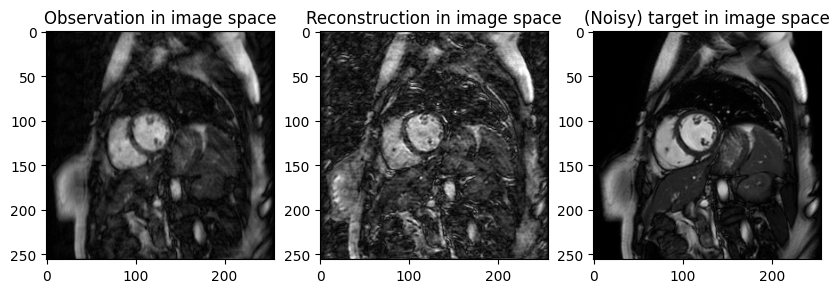

In [139]:
# affichage

fig, ax = plt.subplots(1, 3, figsize=(10,7))

ax[0].imshow(deprocess_obs(obs_image), cmap='gray', vmin=min_val, vmax=max_val)
ax[1].imshow(deprocess_rec(rec_adv), cmap='gray', vmin=min_val, vmax=max_val)
ax[2].imshow(deprocess_target(target_image), cmap='gray', vmin=min_val, vmax=max_val)

ax[0].set_title('Observation in image space')
ax[1].set_title('Reconstruction in image space')
ax[2].set_title('(Noisy) target in image space')

plt.show()

> Sur la figure obtenue, on observe que l’observation en espace image (colonne de gauche) reste quasiment inchangée : la perturbation est trop faible pour être visible à l’œil nu. En revanche, la reconstruction produite par le réseau (colonne centrale) est fortement dégradée et contient de nombreux artefacts. 
> Cela montre que le modèle de reconstruction est très sensible à de petites perturbations dans les mesures. Bien que le bruit ajouté soit presque invisible dans les observations, il entraîne une détérioration importante de la reconstruction. **Ce comportement illustre l’instabilité des modèles d’apprentissage profond pour les problèmes inverses, comme discuté dans Gottschling et al. (2025).**